### Chatbot with Tools

In [1]:
import os
from dotenv import load_dotenv
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langchain_groq import ChatGroq
from langchain_tavily import TavilySearch
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver

c:\Users\viren\generative-ai-implementations\langchain\agent\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Loading the environment variables
load_dotenv()

groq_api_key = os.getenv('GROQ_API_KEY')
tavily_api_key = os.getenv('TAVILY_API_KEY')

if groq_api_key == None or tavily_api_key == None:
    raise ValueError("Groq/Tavily API Key Not Found!")

In [3]:
# Initializing the llm
llm = ChatGroq(model="llama-3.3-70b-versatile", api_key=groq_api_key)

In [ ]:
# Built-In Tool
search_tool = TavilySearch(max_results = 2, api_key=tavily_api_key)

# Custom Tool
def multiply(a:int, b:int) -> int:
    '''Multiply a and b
    
    Args: 
        a (int) : first int
        b (int) : second int

    returns:
        int: output int
    '''
    return a*b

tools = [search_tool, multiply]

In [ ]:
# Binding the tools with llm
llm_with_tools = llm.bind_tools(tools)

In [5]:
# Defining the State Class
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [7]:
# LLM Node Functionality
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

In [10]:
# Instantiate the StateGraph
builder = StateGraph(State)

# Add Nodes to the StateGraph
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# Add Edges to the StateGraph
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools", END)

# Compile the Graph
graph = builder.compile()

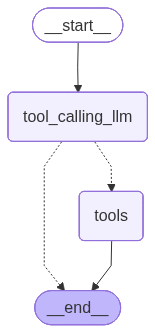

In [11]:
# Visualize the Graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

In [13]:
response = graph.invoke({"messages": "Hi, what are the latest news updates"})

In [27]:
response['messages'][-1].content

'{"query": "latest news updates", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://aviationweek.com/air-transport/airports-networks/airport-updates-latest-news-global-market-wc-july-13-2026", "title": "Airport Updates: Latest News On The Global Market (W/C July 13, 2026) - Aviation Week", "score": 0.6010557, "published_date": "Mon, 13 Jul 2026 09:50:35 GMT", "content": "* Aviation Week & Space Technology - Inside MRO. * CAPA Airline Leader Summit - Airlines in Transition. * CAPA Airline Leader Summit - Americas. * CAPA Airline Leader Summit - Australia Pacific. * CAPA Airline Leader Summit - Asia & Sustainability Awards. * CAPA Airline Leader Summit - World & Awards for Excellence. * CAPA Asia Aviation Summit & Awards for Excellence. # Airport Updates: Latest News On The Global Market (W/C July 13, 2026). The latest news on airports globally, with updates on financing, infrastructure expansion and sustainability initiatives. **Centralny Port Komun

In [28]:
for msg in response['messages']:
    msg.pretty_print()

================================ Human Message =================================

Hi, what are the latest news updates
================================== Ai Message ==================================
Tool Calls:
  tavily_search (pa7r7dvtv)
 Call ID: pa7r7dvtv
  Args:
    query: latest news updates
    search_depth: basic
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest news updates", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://aviationweek.com/air-transport/airports-networks/airport-updates-latest-news-global-market-wc-july-13-2026", "title": "Airport Updates: Latest News On The Global Market (W/C July 13, 2026) - Aviation Week", "score": 0.6010557, "published_date": "Mon, 13 Jul 2026 09:50:35 GMT", "content": "* Aviation Week & Space Technology - Inside MRO. * CAPA Airline Leader Summit - Airlines in Transition. * CAPA Airline Leader Summit - Americas. * C

In [29]:
response_m = graph.invoke({"messages": "What is 3467 * 34567"})
for msg in response_m['messages']:
    msg.pretty_print()

================================ Human Message =================================

What is 3467 * 34567
================================== Ai Message ==================================
Tool Calls:
  multiply (ctdk9xs8g)
 Call ID: ctdk9xs8g
  Args:
    a: 3467
    b: 34567
================================= Tool Message =================================
Name: multiply

119843789


### ReAct Agent Architecture - Act, Obeserve, Reason

In [ ]:
# Instantiate the StateGraph
builder = StateGraph(State)

# Add Nodes to the StateGraph
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# Add Edges to the StateGraph
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")

# Compile the Graph
graph = builder.compile()

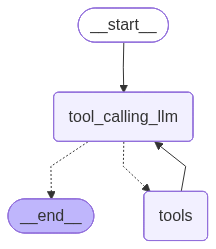

In [31]:
# Visualize the Graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

In [32]:
response = graph.invoke({"messages": "What is 3467 * 34567 and the latest ai news"})
for msg in response['messages']:
    msg.pretty_print()

================================ Human Message =================================

What is 3467 * 34567 and the latest ai news
================================== Ai Message ==================================
Tool Calls:
  multiply (rvzefhcz5)
 Call ID: rvzefhcz5
  Args:
    a: 3467
    b: 34567
  tavily_search (2x6c9a847)
 Call ID: 2x6c9a847
  Args:
    query: latest AI news
    search_depth: advanced
    topic: news
================================= Tool Message =================================
Name: multiply

119843789
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.businessinsider.com/new-ai-model-announcements-openai-meta-grok-2026-7", "title": "The Whirlwind 72 Hours of Rival AI Announcements - Business Insider", "score": 0.7568076, "published_date": "Fri, 10 Jul 2026 15:24:46 GMT", "content": "The last three 

### Adding Memory in Agentic Graph 

In [6]:
memory = MemorySaver()

# Instantiate the StateGraph
builder = StateGraph(State)

# Add Nodes to the StateGraph
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# Add Edges to the StateGraph
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")

# Compile the Graph
graph = builder.compile(checkpointer=memory)

NameError: name 'tool_calling_llm' is not defined

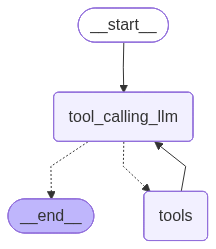

In [14]:
# Visualize the Graph
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

In [15]:
config={"configurable": {"thread_id": "1"}}

response_1 = graph.invoke({"messages": "Hi my name is pranay, what are the latest ai news of today?"}, config=config)
for msg in response_1['messages']:
    msg.pretty_print()

================================ Human Message =================================

Hi my name is pranay, what are the latest ai news of today?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (43b20jj0b)
 Call ID: 43b20jj0b
  Args:
    query: latest AI news today
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news today", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cnbc.com/2026/07/17/moonshot-ai-kimi-k3-model-openai-anthropic-china.html", "title": "Chinese startup Moonshot AI unveils Kimi model it says rivals OpenAI, Anthropic - CNBC", "score": 0.6337056, "published_date": "Fri, 17 Jul 2026 08:38:30 GMT", "content": "Chinese AI rivals' shares dropped on news of the release. Z.ai, which released a new model to much fanfare in June, saw its stock plummet 28% on Friday. Mi

In [16]:
response_1 = graph.invoke({"messages": "what name of mine i told you ?"}, config=config)
for msg in response_1['messages']:
    msg.pretty_print()

================================ Human Message =================================

Hi my name is pranay, what are the latest ai news of today?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (43b20jj0b)
 Call ID: 43b20jj0b
  Args:
    query: latest AI news today
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news today", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cnbc.com/2026/07/17/moonshot-ai-kimi-k3-model-openai-anthropic-china.html", "title": "Chinese startup Moonshot AI unveils Kimi model it says rivals OpenAI, Anthropic - CNBC", "score": 0.6337056, "published_date": "Fri, 17 Jul 2026 08:38:30 GMT", "content": "Chinese AI rivals' shares dropped on news of the release. Z.ai, which released a new model to much fanfare in June, saw its stock plummet 28% on Friday. Mi

### Streaming 

- Streaming are of two kinds : stream() and astream()
- These methods are sync and async methods for streaming back results

Additional parameters in streaming modes for graph state:

- values : This streams the full state of the graph after each node is called
- updates : This streams updates to the state of the graph after each node is called.

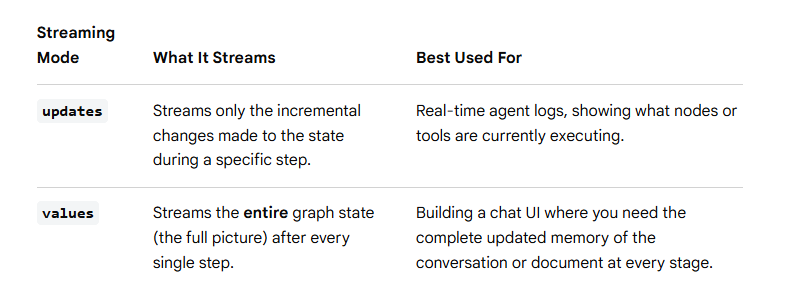

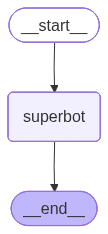

In [11]:

# Defining the State Class
class State(TypedDict):
    messages: Annotated[list, add_messages]

memory = MemorySaver()

def superbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("superbot", superbot)

builder.add_edge(START, "superbot")
builder.add_edge("superbot", END)

graph = builder.compile(checkpointer=memory)

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

In [12]:
config={"configurable": {"thread_id": "1"}}


for msg in graph.stream({"messages": "Hi my name is pranay, what are the latest ai news of today?"}, config=config, stream_mode="updates"):
    print(msg)

{'superbot': {'messages': [AIMessage(content="Hello Pranay, I'm happy to share the latest AI news with you. However, please note that my knowledge cutoff is December 2023, so I might not have the most up-to-date information. That being said, here are some of the recent AI developments that I'm aware of:\n\n1. **Chatbots and Virtual Assistants**: Companies like Google, Amazon, and Microsoft are continuously improving their chatbot and virtual assistant technologies, making them more conversational and user-friendly.\n2. **Generative AI**: Generative models like DALL-E, Midjourney, and Stable Diffusion are gaining popularity, allowing users to create realistic images, videos, and music using text prompts.\n3. **AI in Healthcare**: AI is being used to develop personalized medicine, improve disease diagnosis, and streamline clinical workflows. For example, AI-powered chatbots are being used to help patients with mental health issues.\n4. **Autonomous Vehicles**: Companies like Waymo, Tesla

In [13]:
config={"configurable": {"thread_id": "2"}}


for msg in graph.stream({"messages": "Hi my name is pranay, what are the latest ai news of today?"}, config=config, stream_mode="values"):
    print(msg)

{'messages': [HumanMessage(content='Hi my name is pranay, what are the latest ai news of today?', additional_kwargs={}, response_metadata={}, id='f1c43579-dd8c-4a3f-900c-a74e7e98a280')]}
{'messages': [HumanMessage(content='Hi my name is pranay, what are the latest ai news of today?', additional_kwargs={}, response_metadata={}, id='f1c43579-dd8c-4a3f-900c-a74e7e98a280'), AIMessage(content="Hello Pranay, I'm happy to share the latest AI news with you. Since I'm a large language model, I don't have real-time access to current events, but I can give you an overview of recent developments in the field of AI. Here are some of the latest AI news and trends:\n\n1. **Advances in Natural Language Processing (NLP)**: Researchers have made significant progress in NLP, enabling AI models to better understand and generate human-like language. This has led to improvements in chatbots, language translation, and text summarization.\n2. **Rise of Generative AI**: Generative AI models, such as Generative

In [14]:
config={"configurable": {"thread_id": "3"}}


async for msg in graph.astream_events({"messages": "Hi my name is pranay, what are the latest ai news of today?"}, config=config, version="v2"):
    print(msg)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hi my name is pranay, what are the latest ai news of today?'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019f7141-e9be-7300-be00-643ab1a42618', 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi my name is pranay, what are the latest ai news of today?', additional_kwargs={}, response_metadata={}, id='3f3468c1-81ad-4958-ab20-0d4bcdccad5a')]}}, 'name': 'superbot', 'tags': ['graph:step:1'], 'run_id': '019f7141-e9c3-7551-affb-d4e175be2659', 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'superbot', 'langgraph_triggers': ('branch:to:superbot',), 'langgraph_path': ('__pregel_pull', 'superbot'), 'langgraph_checkpoint_ns': 'superbot:464e1389-740c-0e52-60ee-a17a11828a1e'}, 'parent_ids': ['019f7141-e9be-7300-be00-643ab1a42618']}
{'event': 'on_chat_model_start', 'data'